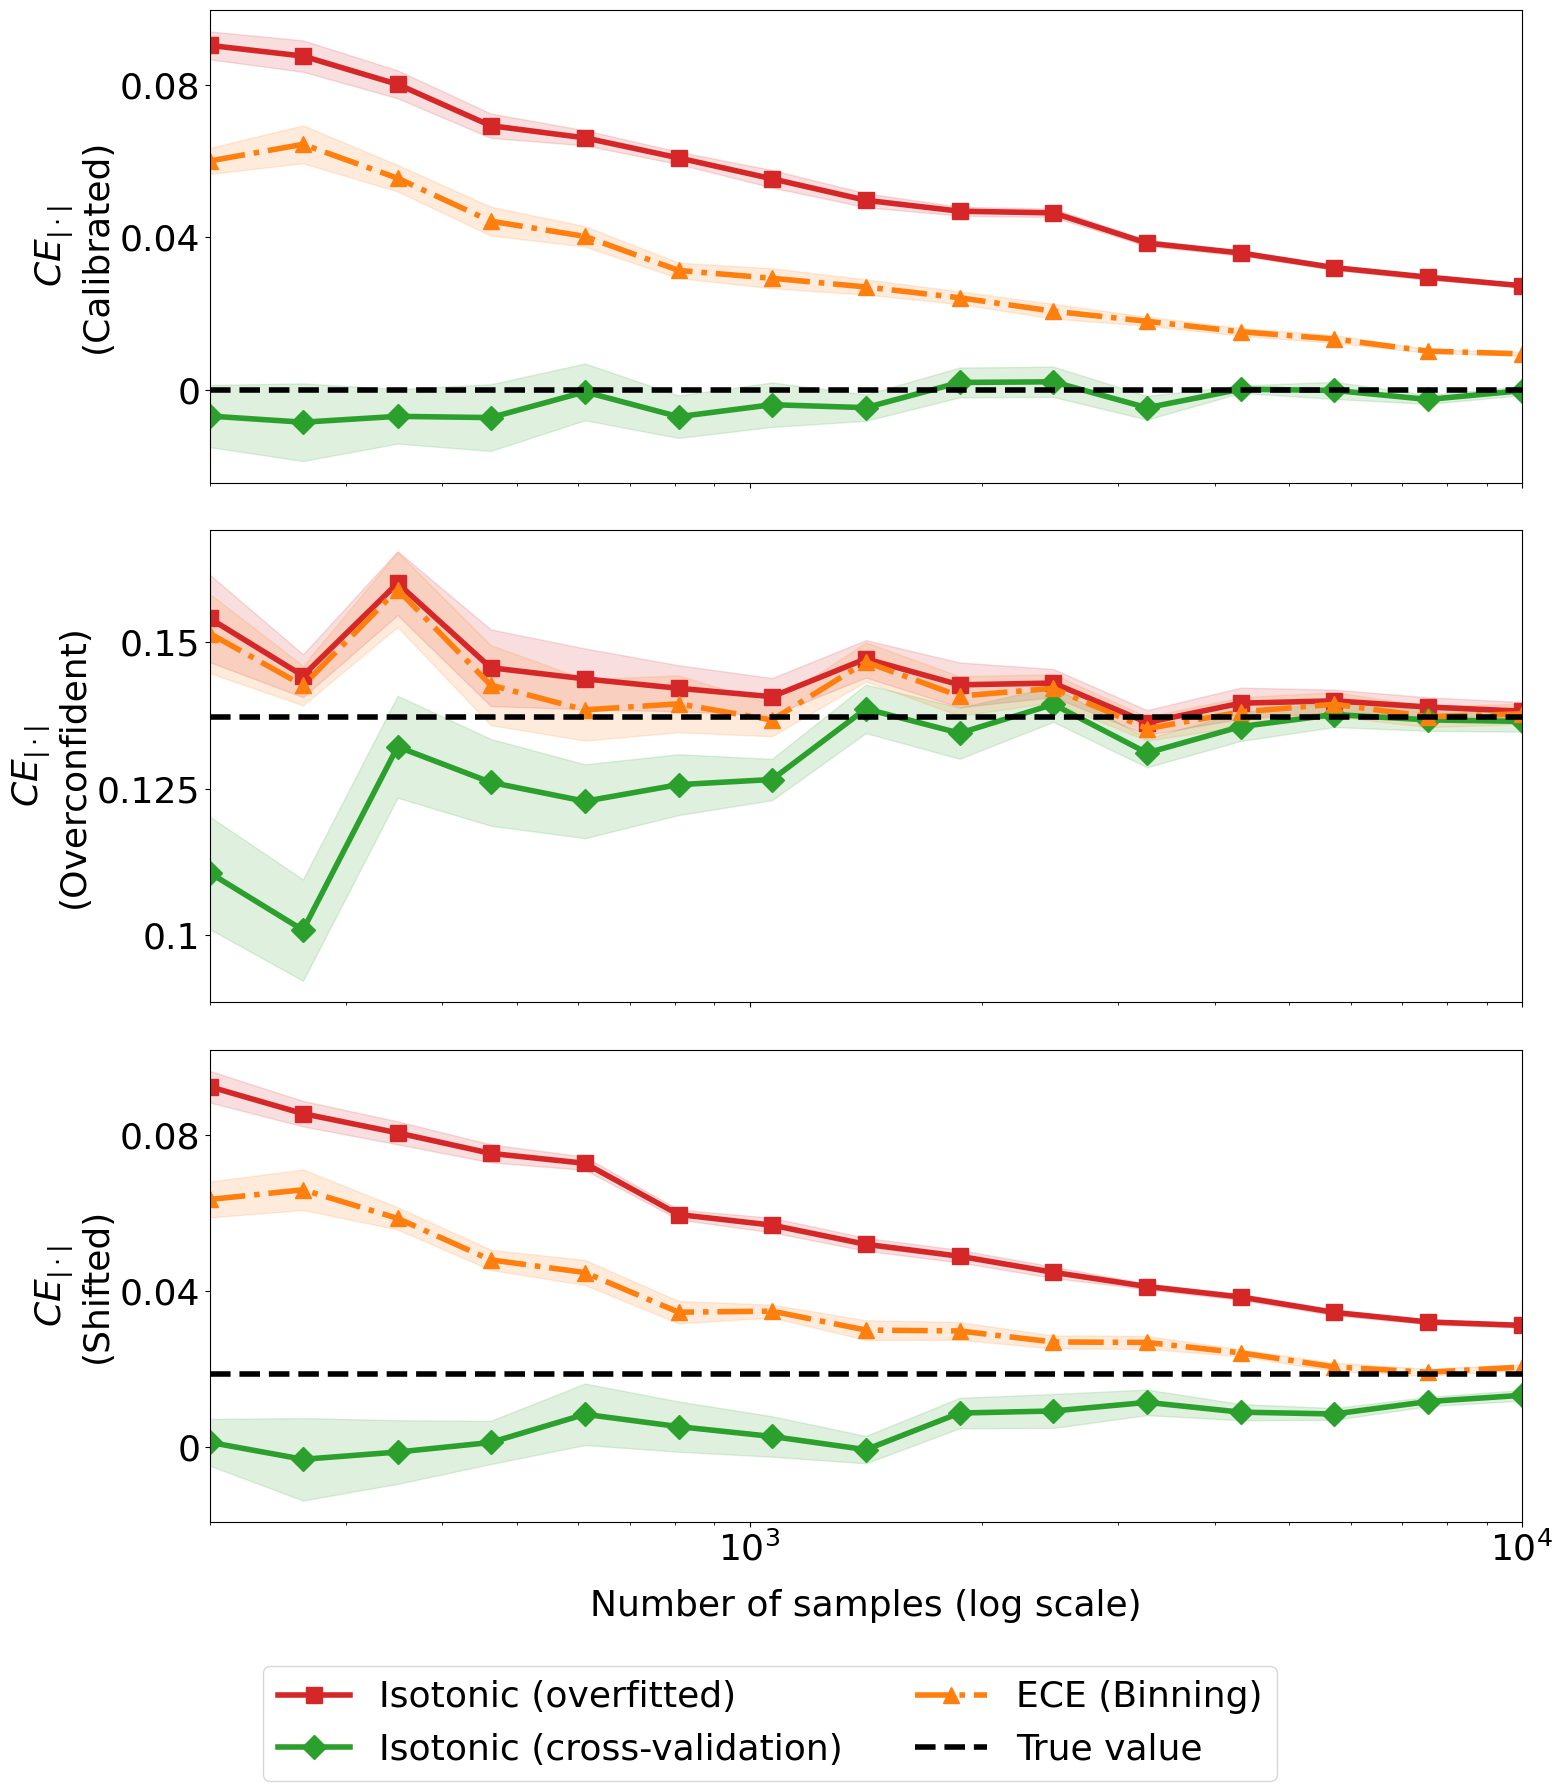

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

df = pd.read_csv("synthetic_binary_V7.csv")

TEXT_SIZE = 26 
TARGET_H_FUNCS = ['perfectly_calibrated_bin', 'overconfident_binary', 'almost_perfectly_calibrated_binary']
cmap = plt.get_cmap('tab10')


methods_config = {
    "overfitted_IsotonicPredictor": {
        "label": "Isotonic (overfitted)", 
        "include": True, 
        "color": cmap(3), 
        "marker": "s",    
        "ls": "-"         
    },
    "IsotonicPredictor": {
        "label": "Isotonic (cross-validation)", 
        "include": True, 
        "color": cmap(2), 
        "marker": "D",      
        "ls": "-"           
    },
    "Binning_Classic": {
        "label": "ECE (Binning)", 
        "include": True, 
        "color": cmap(1), 
        "marker": "^",      
        "ls": "-."          
    }
}

dic_pert = {
    "perfectly_calibrated_bin": "Calibrated",
    'overconfident_binary': "Overconfident", 
    'almost_perfectly_calibrated_binary': "Shifted"
}

h_funcs = [h for h in TARGET_H_FUNCS if h in df['h_func'].unique()]
n_subplots = len(h_funcs)

fig, axes = plt.subplots(n_subplots, 1, figsize=(16, 6 * n_subplots), sharex=True)

if n_subplots == 1:
    axes = [axes]

plot_idx = 0
global_handles, global_labels = [], []

for h in h_funcs:
    ax = axes[plot_idx]
    h_df = df[df['h_func'] == h]
    
    for method_id, config in methods_config.items():
        if not config['include']: continue
        col_name = f"ERT_L1_ECE_{method_id}"
        if col_name in h_df.columns:
            stats = h_df.groupby('n_samples')[col_name].agg(['mean', 'sem']).reset_index()
            line, = ax.plot(stats['n_samples'], stats['mean'], 
                             label=config['label'], color=config['color'],
                             marker=config["marker"], markersize=12, linewidth=4, linestyle=config["ls"])
            ax.fill_between(stats['n_samples'], stats['mean'] - stats['sem'], 
                             stats['mean'] + stats['sem'], color=config['color'], alpha=0.15)
            ax.set_xlim(h_df['n_samples'].min(), h_df['n_samples'].max())
            if plot_idx == 0:
                global_handles.append(line)
                global_labels.append(config['label'])

    true_col = "ERT_L1_ECE_TRUE"
    if true_col in h_df.columns:
        true_stats = h_df.groupby('n_samples')[true_col].mean().sort_index().reset_index()
        line_true, = ax.plot(true_stats['n_samples'], true_stats[true_col], 
                             'k--', label='True value', linewidth=4, zorder=10)
        if plot_idx == 0:
            global_handles.append(line_true)
            global_labels.append('True value')

    ax.set_xscale('log')

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    yticks = ax.get_yticks()
    ax.set_yticks(yticks) 
    ax.set_yticklabels([f"{y:g}" if y >= 0 else "" for y in yticks])

    ax.set_ylabel(r"$CE_{{|\cdot|}}$"+f"\n({dic_pert[h]})", fontsize=TEXT_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TEXT_SIZE)
    ax.label_outer()
    
    ax.label_outer() 
    
    plot_idx += 1

axes[-1].set_xlabel('Number of samples (log scale)', fontsize=TEXT_SIZE, labelpad=15)


fig.legend(global_handles, global_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.08), 
           ncol=2, 
           fontsize=TEXT_SIZE, 
           frameon=True)

plt.subplots_adjust(top=0.99, bottom=0.15, hspace=0.1, left=0.15, right=0.97)
plt.savefig("../figs/synthetic_bin.pdf", dpi=300)
plt.show()

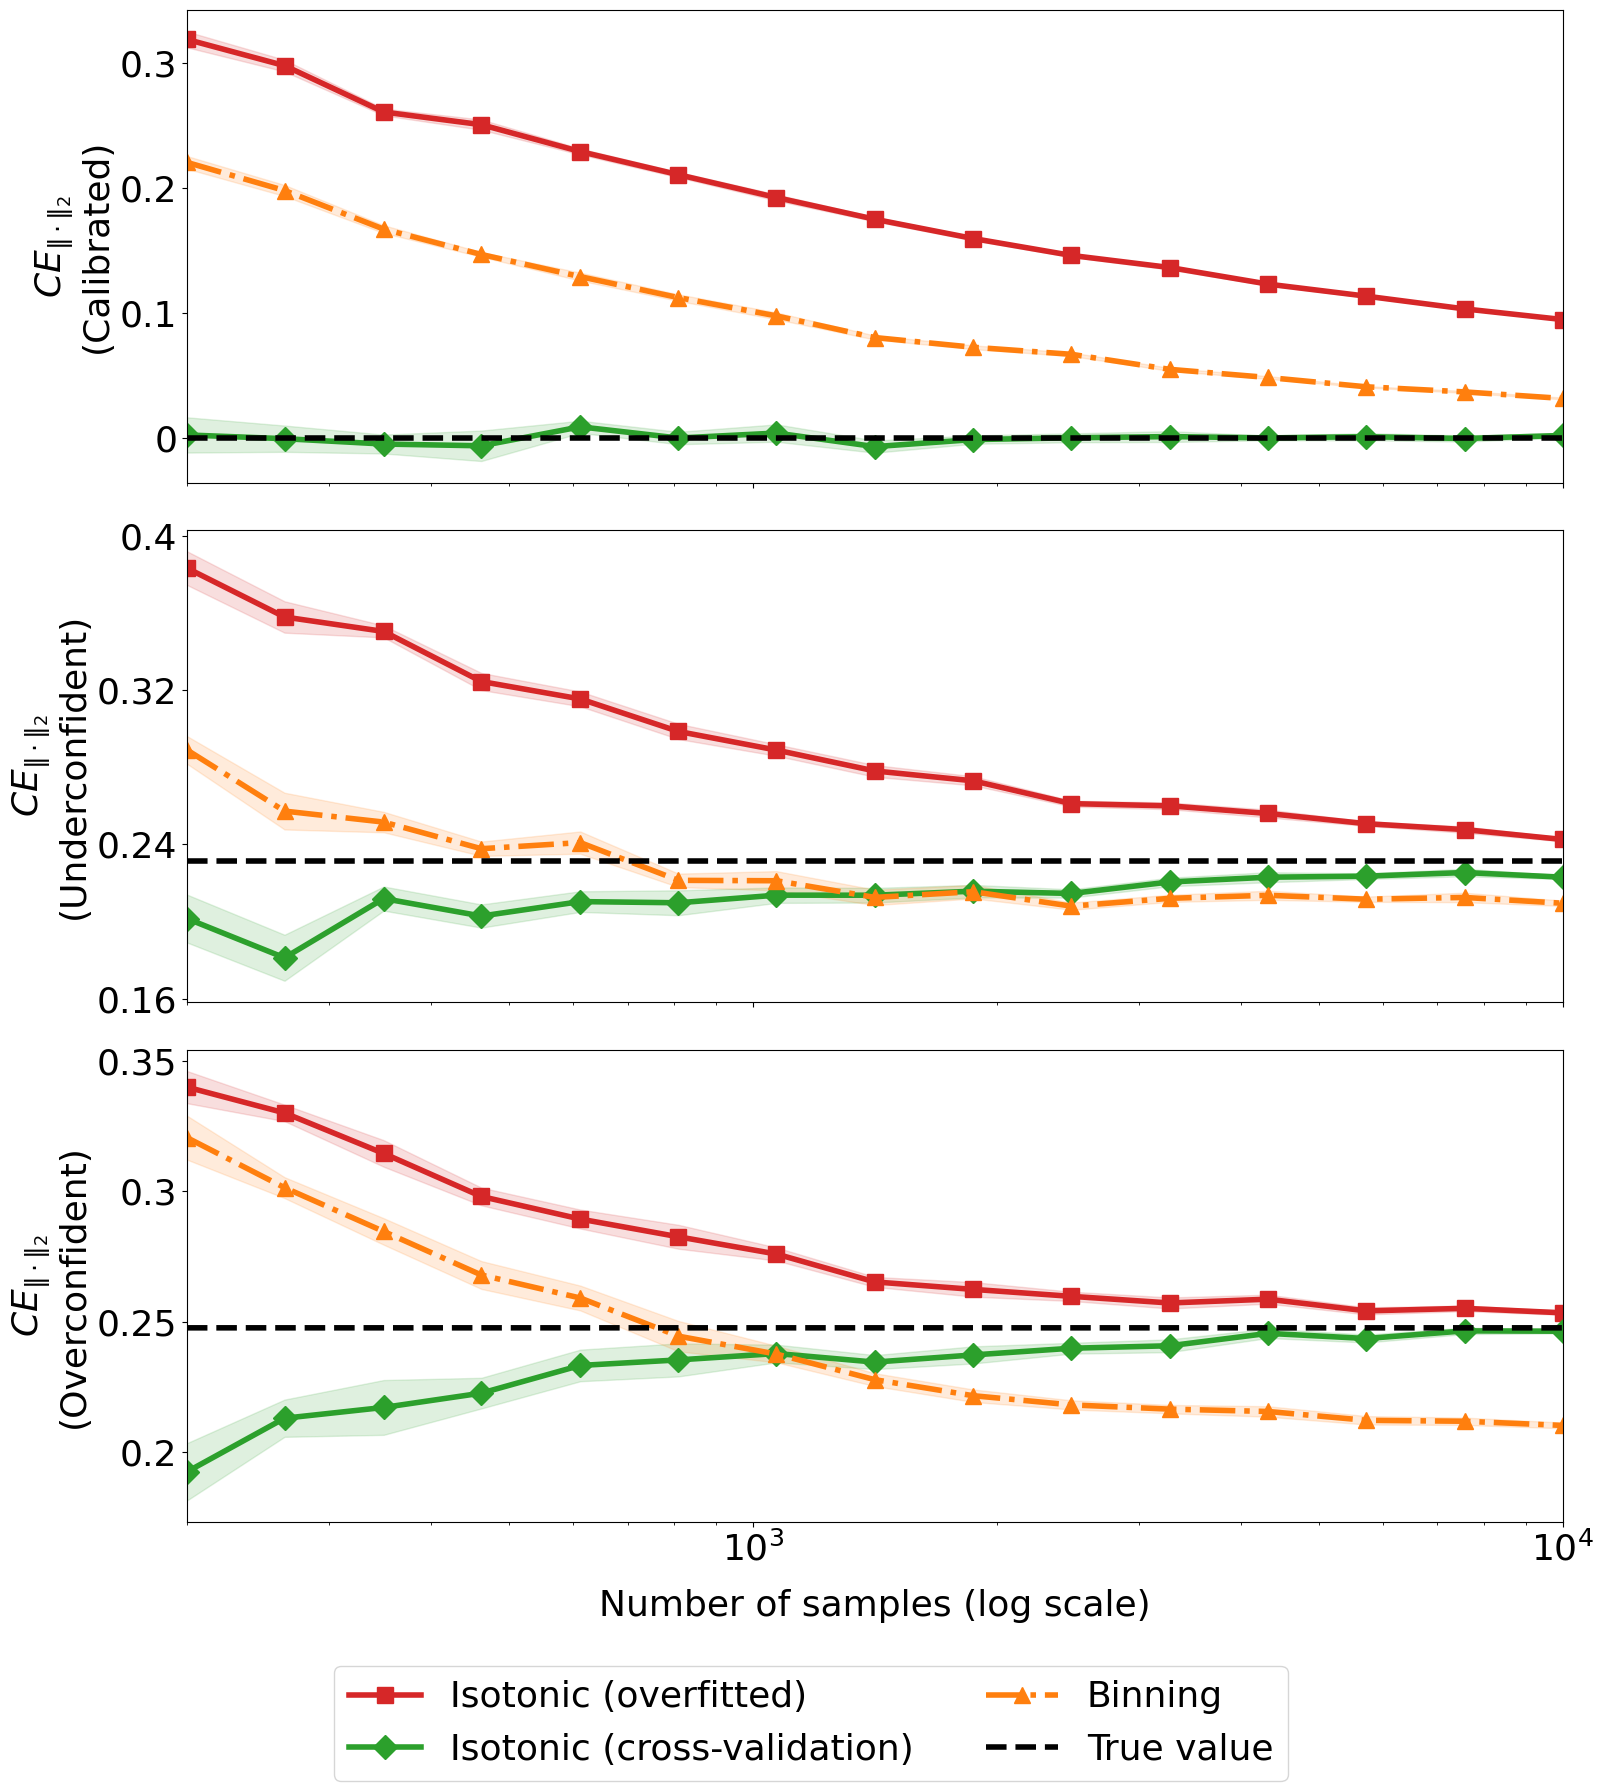

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Hyperparameters ---
dimension = 10
TEXT_SIZE = 26 
TARGET_H_FUNCS = ['perfectly_calibrated_mc', 'underconfident_mc', 'overconfident_mc']
cmap = plt.get_cmap('tab10')


methods_config = {
    "overfitted_IsotonicPredictor": {
        "label": "Isotonic (overfitted)", 
        "include": True, 
        "color": cmap(3), 
        "marker": "s",      
        "ls": "-"           
    },
    "IsotonicPredictor": {
        "label": "Isotonic (cross-validation)", 
        "include": True, 
        "color": cmap(2), 
        "marker": "D",      
        "ls": "-"           
    },
    "Binning_Classic": {
        "label": "Binning", 
        "include": True, 
        "color": cmap(1), 
        "marker": "^",      
        "ls": "-."          
    }
}

dic_pert = {
    "perfectly_calibrated_mc": "Calibrated",
    'underconfident_mc': "Underconfident", 
    'overconfident_mc': "Overconfident" 
}

df = pd.read_csv("synthetic_multiclass_V7.csv")
h_funcs = [h for h in TARGET_H_FUNCS if h in df['h_func'].unique()]
n_subplots = len(h_funcs)

fig, axes = plt.subplots(n_subplots, 1, figsize=(16, 6 * n_subplots), sharex=True)

if n_subplots == 1:
    axes = [axes]

plot_idx = 0
global_handles, global_labels = [], []

for h in h_funcs:
    ax = axes[plot_idx]
    h_df = df[df['h_func'] == h]
    h_df = h_df[h_df['n_classes'] == dimension]
    
    for method_id, config in methods_config.items():
        if not config['include']: continue
        col_name = f"ERT_generalized_norm_score_2_{method_id}" # ERT_generalized_norm_score_2 ERT_L1_ECE_
        if col_name in h_df.columns:
            stats = h_df.groupby('n_samples')[col_name].agg(['mean', 'sem']).reset_index()
            line, = ax.plot(stats['n_samples'], stats['mean'], 
                             label=config['label'], color=config['color'],
                             marker=config["marker"], markersize=12, linewidth=4, linestyle=config["ls"])
            ax.fill_between(stats['n_samples'], stats['mean'] - stats['sem'], 
                             stats['mean'] + stats['sem'], color=config['color'], alpha=0.15)
            ax.set_xlim(h_df['n_samples'].min(), h_df['n_samples'].max())
            if plot_idx == 0:
                global_handles.append(line)
                global_labels.append(config['label'])


    true_col = "ERT_generalized_norm_score_2_TRUE" # ERT_generalized_norm_score_2_Binning_Classic ERT_L1_ECE_TRUE
    if true_col in h_df.columns:
        true_stats = h_df.groupby('n_samples')[true_col].mean().sort_index().reset_index()
        line_true, = ax.plot(true_stats['n_samples'], true_stats[true_col], 
                             'k--', label='True value', linewidth=4, zorder=10)
        if plot_idx == 0:
            global_handles.append(line_true)
            global_labels.append('True value')

    
    ax.set_xscale('log')
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    yticks = ax.get_yticks()
    ax.set_yticks(yticks) 
    ax.set_yticklabels([f"{y:g}" if y >= 0 else "" for y in yticks])

    ax.set_ylabel(r"$CE_{{\|\cdot\|_2}}$"+f"\n({dic_pert[h]})", fontsize=TEXT_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TEXT_SIZE)
    ax.label_outer()
    
    ax.label_outer() 
    
    plot_idx += 1

axes[-1].set_xlabel('Number of samples (log scale)', fontsize=TEXT_SIZE, labelpad=15)

fig.legend(global_handles, global_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.08), 
           ncol=2, 
           fontsize=TEXT_SIZE, 
           frameon=True)

plt.subplots_adjust(top=0.99, bottom=0.15, hspace=0.1, left=0.11, right=0.97)
plt.savefig(f"../figs/synthetic_multi_L2_d={dimension}.pdf", dpi=300)
plt.show()

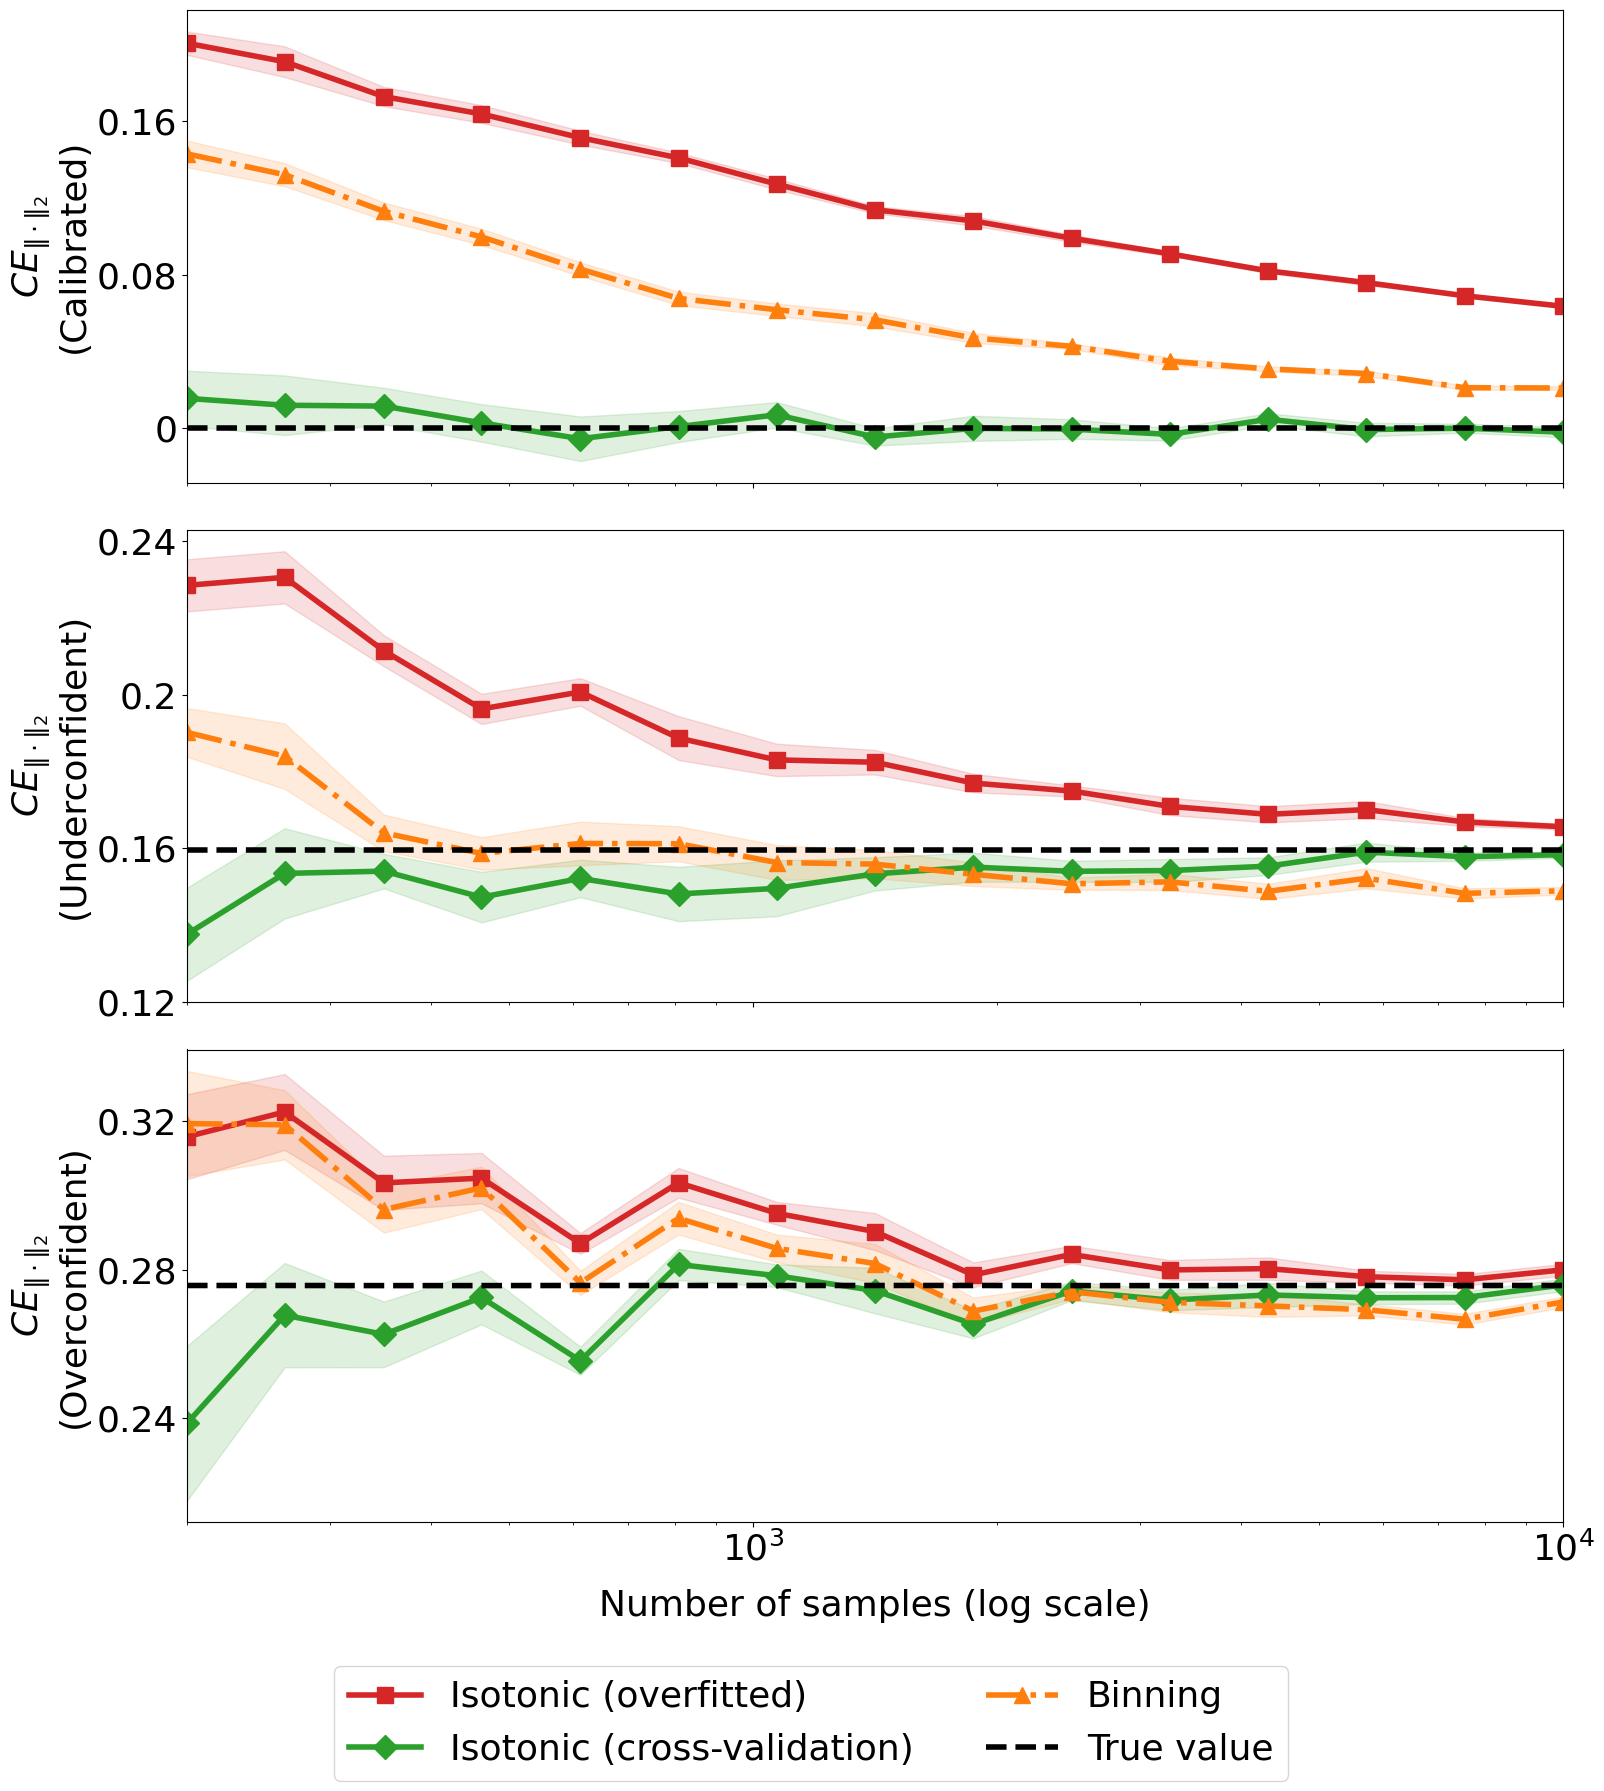

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Hyperparameters ---
dimension = 3
TEXT_SIZE = 26 
TARGET_H_FUNCS = ['perfectly_calibrated_mc', 'underconfident_mc', 'overconfident_mc']
cmap = plt.get_cmap('tab10')


methods_config = {
    "overfitted_IsotonicPredictor": {
        "label": "Isotonic (overfitted)", 
        "include": True, 
        "color": cmap(3), 
        "marker": "s",      
        "ls": "-"           
    },
    "IsotonicPredictor": {
        "label": "Isotonic (cross-validation)", 
        "include": True, 
        "color": cmap(2), 
        "marker": "D",      
        "ls": "-"           
    },
    "Binning_Classic": {
        "label": "Binning", 
        "include": True, 
        "color": cmap(1), 
        "marker": "^",      
        "ls": "-."          
    }
}

dic_pert = {
    "perfectly_calibrated_mc": "Calibrated",
    'underconfident_mc': "Underconfident", 
    'overconfident_mc': "Overconfident" 
}

df = pd.read_csv("synthetic_multiclass_V7.csv")
h_funcs = [h for h in TARGET_H_FUNCS if h in df['h_func'].unique()]
n_subplots = len(h_funcs)

fig, axes = plt.subplots(n_subplots, 1, figsize=(16, 6 * n_subplots), sharex=True)

if n_subplots == 1:
    axes = [axes]

plot_idx = 0
global_handles, global_labels = [], []

for h in h_funcs:
    ax = axes[plot_idx]
    h_df = df[df['h_func'] == h]
    h_df = h_df[h_df['n_classes'] == dimension]
    
    for method_id, config in methods_config.items():
        if not config['include']: continue
        col_name = f"ERT_generalized_norm_score_2_{method_id}" # ERT_generalized_norm_score_2 ERT_L1_ECE_
        if col_name in h_df.columns:
            stats = h_df.groupby('n_samples')[col_name].agg(['mean', 'sem']).reset_index()
            line, = ax.plot(stats['n_samples'], stats['mean'], 
                             label=config['label'], color=config['color'],
                             marker=config["marker"], markersize=12, linewidth=4, linestyle=config["ls"])
            ax.fill_between(stats['n_samples'], stats['mean'] - stats['sem'], 
                             stats['mean'] + stats['sem'], color=config['color'], alpha=0.15)
            ax.set_xlim(h_df['n_samples'].min(), h_df['n_samples'].max())
            if plot_idx == 0:
                global_handles.append(line)
                global_labels.append(config['label'])


    true_col = "ERT_generalized_norm_score_2_TRUE" # ERT_generalized_norm_score_2_Binning_Classic ERT_L1_ECE_TRUE
    if true_col in h_df.columns:
        true_stats = h_df.groupby('n_samples')[true_col].mean().sort_index().reset_index()
        line_true, = ax.plot(true_stats['n_samples'], true_stats[true_col], 
                             'k--', label='True value', linewidth=4, zorder=10)
        if plot_idx == 0:
            global_handles.append(line_true)
            global_labels.append('True value')

    
    ax.set_xscale('log')
    
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    yticks = ax.get_yticks()
    ax.set_yticks(yticks) 
    ax.set_yticklabels([f"{y:g}" if y >= 0 else "" for y in yticks])

    ax.set_ylabel(r"$CE_{{\|\cdot\|_2}}$"+f"\n({dic_pert[h]})", fontsize=TEXT_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TEXT_SIZE)
    ax.label_outer()
    
    ax.label_outer() 
    
    plot_idx += 1

axes[-1].set_xlabel('Number of samples (log scale)', fontsize=TEXT_SIZE, labelpad=15)

fig.legend(global_handles, global_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.08), 
           ncol=2, 
           fontsize=TEXT_SIZE, 
           frameon=True)

plt.subplots_adjust(top=0.99, bottom=0.15, hspace=0.1, left=0.11, right=0.97)
plt.savefig(f"../figs/synthetic_multi_L2_d={dimension}.pdf", dpi=300)
plt.show()